In [11]:
import warnings
import datetime as dt
from datetime import timedelta
import xarray as xr
import math
import time as tm
import pytz
import numpy as np
import pandas as pd
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
import xarray
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from netCDF4 import Dataset


warnings.filterwarnings('ignore')



In [12]:
SM10CM_1pct = xr.open_dataset('/glade/work/afallah/data_prj1_caleb/10cmSM_CESM2_C4MIP_CMIP6-1pctCO2_hist_lnd.nc')
SM10CM_bgc = xr.open_dataset('/glade/work/afallah/data_prj1_caleb/10cmSM_CESM2_C4MIP_CMIP6_1pctCO2_bgc_hist_lnd.nc')
SM10CM_rad = xr.open_dataset('/glade/work/afallah/data_prj1_caleb/10cmSM_CESM2_C4MIP_CMIP6_1pctCO2_rad_hist_lnd.nc')

In [13]:
#Selecting time period
#SM10CM
SM10CM_1pct = SM10CM_1pct.sel(time=slice('0001-02-01', '0020-01-01'))
SM10CM_bgc = SM10CM_bgc.sel(time=slice('0001-02-01', '0020-01-01'))
SM10CM_rad = SM10CM_rad.sel(time=slice('0001-02-01', '0020-01-01'))

In [14]:
SM10CM_1pct

<xarray.Dataset>
Dimensions:         (time: 6905, lon: 288, lat: 192)
Coordinates:
  * time            (time) object 0001-02-01 00:00:00 ... 0020-01-01 00:00:00
  * lon             (lon) float32 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lat             (lat) float32 -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
Data variables:
    SOILWATER_10CM  (time, lat, lon) float32 ...

In [15]:
lon = SM10CM_1pct['lon']
lat = SM10CM_1pct['lat']

In [16]:
#Accessing arrays 
#SM10CM
SM10CM_1pct_a = SM10CM_1pct.SOILWATER_10CM
SM10CM_bgc_a = SM10CM_bgc.SOILWATER_10CM
SM10CM_rad_a = SM10CM_rad.SOILWATER_10CM

In [17]:
#Select growing season
SM10CM_1pct_a = SM10CM_1pct_a.sel(time=SM10CM_1pct_a.time.dt.month.isin([4,5,6,7,8,9,10]))
SM10CM_bgc_a = SM10CM_bgc_a.sel(time=SM10CM_bgc_a.time.dt.month.isin([4,5,6,7,8,9,10]))
SM10CM_rad_a = SM10CM_rad_a.sel(time=SM10CM_rad_a.time.dt.month.isin([4,5,6,7,8,9,10]))

In [18]:
#Convert to intervals of weeks
SM10CM_1pct_a = SM10CM_1pct_a.resample( time="7D").mean()
SM10CM_bgc_a = SM10CM_bgc_a.resample( time="7D").mean()
SM10CM_rad_a = SM10CM_rad_a.resample( time="7D").mean()

In [19]:
import cftime

#true
#consecutive dry weeks function
def flashdrought(da1,SM10CM_1pct):
    
    #note the CMIP6 timestamps are different from NLDAS analysis!


     # Create cftime.DatetimeNoLeap objects
    start_date = cftime.DatetimeNoLeap(1, 4, 1, 0, 0, 0, 0, has_year_zero=True)
    end_date = cftime.DatetimeNoLeap(19, 10, 31, 0, 0, 0, 0, has_year_zero=True)
    num_periods = 970

    # Generate an array of cftime.DatetimeNoLeap objects
    delta = (end_date - start_date) / (num_periods - 1)
    dates = [start_date + i * delta for i in range(num_periods)]


    # Create xarray DataArray using the cftime.DatetimeNoLeap objects
    da1 = xr.DataArray(da1, coords=[dates], dims=['time'])
    SM10CM_1pct = xr.DataArray(SM10CM_1pct, coords=[dates], dims=['time'])
    
    # Extract week of the year as a new variable
    da1['week_of_year'] = da1.time.dt.strftime('%W')   #here a week is extra and should be excluded 
    SM10CM_1pct['week_of_year'] = SM10CM_1pct.time.dt.strftime('%W')   #here a week is extra and should be excluded 


  
    fd = np.zeros(len(da1)-1+31)
    fd_DROUGHT = np.zeros(len(da1)-1+31)
    onset_drought = np.zeros(len(da1)-1+31)   #not sure 
    S = np.zeros(len(da1)-1+31)
    onset = np.zeros(len(da1)-1+31)
    onset_20 = np.zeros(len(da1)-1+31)
    #SM_q20 = np.nanquantile(da1, [0.20])
    #SM_q40 = np.nanquantile(da1, [0.40])
    
        
        
    percentile_20_climato = SM10CM_1pct.groupby("week_of_year").quantile(0.2, dim="time")#.compute()   ##this cosde assumes thresholds are caclculated based on 1pct  #time.week has been updated to week_of_year
    percentile_40_climato = SM10CM_1pct.groupby("week_of_year").quantile(0.4, dim="time")#.compute()


    
    #Expand the weekly climatological percentiles to match the shape of the original data
    percentile_20_climato_exp = percentile_20_climato.sel(week_of_year=da1['week_of_year'])#, method='nearest')
    percentile_40_climato_exp = percentile_40_climato.sel(week_of_year=da1['week_of_year'])#, method='nearest')
    
    #Note weekly_climatological_exp is similar to the original data and no need to exclude 1-8 beginning months of 1980!!!    
    SM_q20 = percentile_20_climato_exp
    SM_q40 = percentile_40_climato_exp
    
    da = da1.values
    SM_q20 = SM_q20.values
    SM_q40 = SM_q40.values

    
    #first compute flash drought binary fd 
    for i in range(31,len(da1)-1):
        
        if da[i-2] <=  SM_q20[i-2] and da[i-1] <=  SM_q20[i-1] and da[i] <=  SM_q20[i]: #two weeks below 20 percentile!  #duration is at least 2 weeks 
            
            if da[i-3] >= SM_q40[i-3] or da[i-4] >= SM_q40[i-4] or da[i-5] >= SM_q40[i-5]:
                
                onset_20[i-2] = 1  #onset better than onset_20
                fd[i-2] = 1
                fd[i-1] = 1
                fd[i] = 1
                S[i-2] = da[i-2] - SM_q40[i-2]
                S[i-1] = da[i-1] - SM_q40[i-1]
                S[i] = da[i] - SM_q40[i]
                    


                    
                #FD termination    
                for k in range(i+1,len(da1)-1):    #interesting no need to define end of growing season, fishiy a bit!
                    if da[k] < SM_q20[k]:
                        fd[k] = 1
                        S[k]= da[k] - SM_q40[k]
                        
                    else:
                        #fd[k] = 0    #it must be commented 
                        break
    
    #second compute duration 
    count = 0
    du = np.zeros(len(da1)-1+31)
    
    for i in range(31,len(da1)-2):
        
        if fd[i+1] > fd[i]:
            count=0
            onset[i+1]=1  #represnt frequency
            
            for k in range(i+2,len(da1)):
                if fd[k] == fd[k-1]:
                    count+=1
                    du[k-1]=0
                    du[k]=count
                    
                    if k == i+5:
                        onset_drought[i+5] = 1    #number of DROUGHT events (with duration >=5 weeks)   #recently added to calcluate how many percentage evended up with Drought 

                    
                    if k==30 or k==82 or k==134 or k==186 or k==239 or k==291 or k==343 or k==395 or k==447 or k==499 or k==551 or k==604 or k==656 or k==703 or k==756 or k==808 or k==860 or k==916 or k==969:
                        break
                        
                else:      #later add the condition related to the end of growing season! only very small reqion with dur=1
                    break
 
    
    #return (fd) 
    #return onset
    return (du)   #output is a vector showing duration   
    

In [34]:
#SM10CM = SM10CM_1pct_a    #repeat 3times    
SM10CM = SM10CM_bgc_a      #repeat 3times
#SM10CM = SM10CM_rad_a     #repeat 3times

In [35]:
%%time
#three_dim = xr.apply_ufunc(flashdrought, SM10CM, SM10CM_1pct_a, input_core_dims=[["time"], ["time"]], output_core_dims=[["time_new"]], dask = 'allowed', vectorize = True).rename({'time_new': 'time'})      #the only issue for apply_ufunc is na! this is the case for both flashdrought3 and flashdrought!!!!!!!!!!!!!!!!!!!! Solve first for flashdrought3!!!!!!!!!   Reminder only dask: -1 according to stackoverflow!!!
#onset = xr.apply_ufunc(flashdrought, SM10CM, SM10CM_1pct_a, input_core_dims=[["time"], ["time"]], output_core_dims=[["time_new"]], dask = 'allowed', vectorize = True).rename({'time_new': 'time'})      #the only issue for apply_ufunc is na! this is the case for both flashdrought3 and flashdrought!!!!!!!!!!!!!!!!!!!! Solve first for flashdrought3!!!!!!!!!   Reminder only dask: -1 according to stackoverflow!!!
Duration = xr.apply_ufunc(flashdrought, SM10CM, SM10CM_1pct_a, input_core_dims=[["time"], ["time"]], output_core_dims=[["time_new"]], dask = 'allowed', vectorize = True).rename({'time_new': 'time'})      #the only issue for apply_ufunc is na! this is the case for both flashdrought3 and flashdrought!!!!!!!!!!!!!!!!!!!! Solve first for flashdrought3!!!!!!!!!   Reminder only dask: -1 according to stackoverflow!!!

CPU times: user 1h 30min 50s, sys: 11.8 s, total: 1h 31min 2s
Wall time: 1h 35min 18s


In [36]:
#1 = flash drought in binary (% of time)
#binary = xr.DataArray(data=three_dim.isel(time=slice(0,three_dim.time.size-31+1)), dims=["lat", "lon","time"], coords=[lat,lon,SM10CM.time])
#binary_onset = xr.DataArray(data=onset.isel(time=slice(0,onset.time.size-31+1)), dims=["lat", "lon","time"], coords=[lat,lon,SM10CM.time])
binary_dur = xr.DataArray(data=Duration.isel(time=slice(0,Duration.time.size-31+1)), dims=["lat", "lon","time"], coords=[lat,lon,SM10CM.time])

In [19]:
###DO NOT OVERWRITE

#binary.to_netcdf('/glade/work/afallah/data_prj1_caleb/FD_outputs/Binary_1pct_SM10CM_pctT_thresholds_1pct_clima_percentiles.nc', mode='w')   #could be ...truncated if only consider the rapid intensification period
#binary_onset.to_netcdf('/glade/work/afallah/data_prj1_caleb/FD_outputs/Binary_1pct_SM10CM_freq_thresholds_1pct_clima_percentiles.nc', mode='w')   #could be ...truncated if only consider the rapid intensification period
#binary_dur.to_netcdf('/glade/work/afallah/data_prj1_caleb/FD_outputs/Binary_1pct_SM10CM_dur_thresholds_1pct_clima_percentiles.nc', mode='w')   #could be ...truncated if only consider the rapid intensification period

#binary.to_netcdf('/glade/work/afallah/data_prj1_caleb/FD_outputs/Binary_bgc_SM10CM_pctT_thresholds_1pct_clima_percentiles.nc', mode='w')   #could be ...truncated if only consider the rapid intensification period
#binary_onset.to_netcdf('/glade/work/afallah/data_prj1_caleb/FD_outputs/Binary_bgc_SM10CM_freq_thresholds_1pct_clima_percentiles.nc', mode='w')   #could be ...truncated if only consider the rapid intensification period
#binary_dur.to_netcdf('/glade/work/afallah/data_prj1_caleb/FD_outputs/Binary_bgc_SM10CM_dur_thresholds_1pct_clima_percentiles.nc', mode='w')   #could be ...truncated if only consider the rapid intensification period

#binary.to_netcdf('/glade/work/afallah/data_prj1_caleb/FD_outputs/Binary_rad_SM10CM_pctT_thresholds_1pct_clima_percentiles.nc', mode='w')   #could be ...truncated if only consider the rapid intensification period
#binary_onset.to_netcdf('/glade/work/afallah/data_prj1_caleb/FD_outputs/Binary_rad_SM10CM_freq_thresholds_1pct_clima_percentiles.nc', mode='w')   #could be ...truncated if only consider the rapid intensification period
#binary_dur.to_netcdf('/glade/work/afallah/data_prj1_caleb/FD_outputs/Binary_rad_SM10CM_dur_thresholds_1pct_clima_percentiles.nc', mode='w')   #could be ...truncated if only consider the rapid intensification period

#convert to netCDF

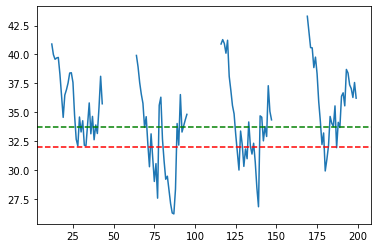

In [15]:
sm = SM10CM_rad_a.sel(lon=301.25,lat=47.59162, time=slice('0012-01-01','0015-12-31'))
plt.plot(sm)
plt.axhline(y=SM10CM_rad_a.sel(lon=301.25,lat=47.59162, method="nearest").quantile([0.20], 'time'), color='r', linestyle='dashed', label='20 percentile')    #20 percentile = 29.8
plt.axhline(y=SM10CM_rad_a.sel(lon=301.25,lat=47.59162, method="nearest").quantile([0.40], 'time'), color='g', linestyle='dashed', label='40 percentile')     #40 percentile = 31.2

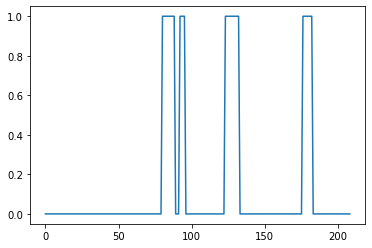

In [16]:
fd = binary.sel(lon=301.25,lat=47.59162, time=slice('0012-01-01','0015-12-31'))
plt.plot(fd)

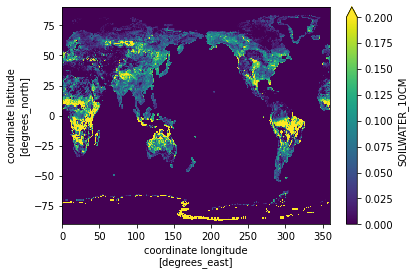

In [17]:
binary.mean(dim = 'time').plot(vmin=0,vmax=0.2) #Map descriptions are not acurate

In [18]:
fd = binary_onset.sel(lon=301.25,lat=47.59162, time=slice('0012-01-01','0015-12-31'))
plt.plot(fd)

NameError: name 'binary_onset' is not defined

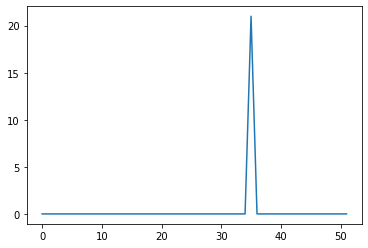

In [237]:
fd = binary_dur.sel(lon=251.25-3*1.25,lat=26.858639, time=slice('0015-01-01','0015-12-31'))
plt.plot(fd)

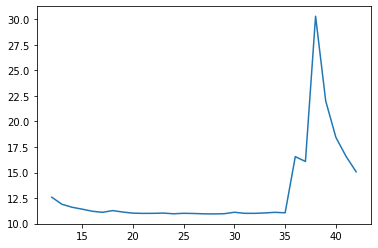

In [218]:
SM = SM10CM_rad_a.sel(lon=251.25-3*1.25,lat=26.858639, time=slice('0015-01-01','0015-12-31'))
plt.plot(SM)

In [82]:
#sm_bgc_lnd.mean(dim = 'time').plot() #Map descriptions are not acurate

In [83]:
#binary.mean(dim = 'time').plot(vmin=0,vmax=0.2) #Map descriptions are not acurate


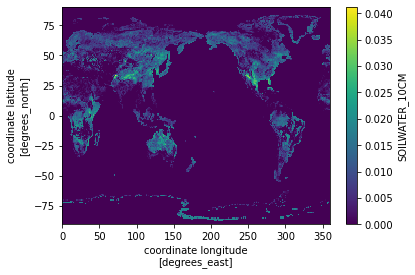

In [26]:
binary_onset.mean(dim = 'time').plot() #Map descriptions are not acurate

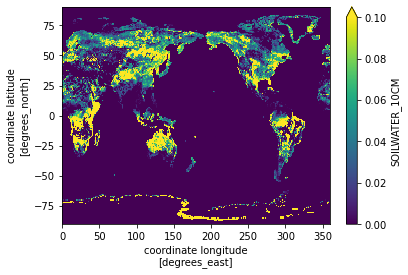

In [32]:
binary_dur.mean(dim = 'time').plot(vmin=0,vmax=.1) #Map descriptions are not acurate


In [38]:
binary_dur_nz = binary_dur.where(binary_dur !=0)
binary_dur_nz.min()

<xarray.DataArray 'SOILWATER_10CM' ()>
array(1.)

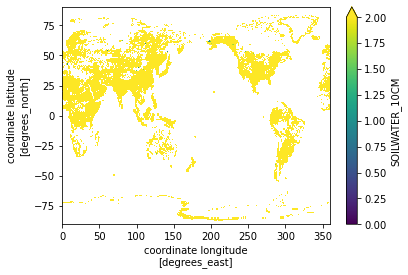

In [39]:
binary_dur_nz.mean(dim = 'time').plot(vmin=0,vmax=2) #Map descriptions are not acurate


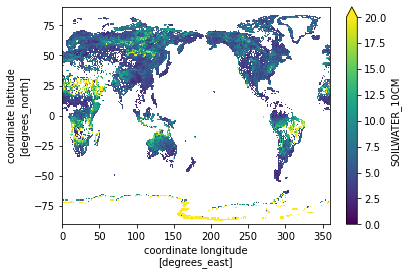

In [34]:
binary_dur_nz.mean(dim = 'time').plot(vmin=0,vmax=20) #Map descriptions are not acurate


In [35]:
binary_dur_nz.max()

<xarray.DataArray 'SOILWATER_10CM' ()>
array(30.)